# OR / Procedure Room Utilization — Exploratory Analysis

This notebook walks through the `or_utilization` package on the synthetic sample
dataset (`data/sample_schedule.csv`), from raw CSV to utilization metrics to
a "what-if" schedule optimization simulation.

**Context:** this project grew out of watching first-hand how much OR time gets
lost to late starts, slow turnarounds, and last-minute cancellations while
working in a hospital surgery department. None of the data here is real patient
or hospital data — it's fully synthetic, generated by `scripts/generate_sample_data.py`
to have realistic statistical properties (cancellation rates, turnaround
distributions, cascading delays) without exposing anything sensitive.

In [1]:
import sys

sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd

from or_utilization.loader import load_schedule
from or_utilization.metrics import compute_metrics
from or_utilization.simulate import compare_scenarios, simulate_schedule_optimization

pd.set_option("display.max_columns", None)
%matplotlib inline

## 1. Load the schedule data

In [2]:
df = load_schedule("../data/sample_schedule.csv")
df.head()

,room_id,date,scheduled_start,scheduled_end,actual_start,actual_end,procedure_type,surgeon_id,status,block_start,block_end,scheduled_start_dt,scheduled_end_dt,actual_start_dt,actual_end_dt,block_start_dt,block_end_dt
0,OR-1,2025-01-06,07:00,09:03,07:01,09:21,Total Knee Arthroplasty,SUR-011,completed,07:00,17:00,2025-01-06 07:00:00,2025-01-06 09:03:00,2025-01-06 07:01:00,2025-01-06 09:21:00,2025-01-06 07:00:00,2025-01-06 17:00:00
1,OR-1,2025-01-06,09:50,10:38,09:50,10:40,Laparoscopic Cholecystectomy,SUR-011,completed,07:00,17:00,2025-01-06 09:50:00,2025-01-06 10:38:00,2025-01-06 09:50:00,2025-01-06 10:40:00,2025-01-06 07:00:00,2025-01-06 17:00:00
2,OR-1,2025-01-06,10:59,11:53,10:59,12:04,Hernia Repair,SUR-011,completed,07:00,17:00,2025-01-06 10:59:00,2025-01-06 11:53:00,2025-01-06 10:59:00,2025-01-06 12:04:00,2025-01-06 07:00:00,2025-01-06 17:00:00
3,OR-1,2025-01-07,07:00,07:38,07:06,07:36,Tonsillectomy,SUR-011,completed,07:00,17:00,2025-01-07 07:00:00,2025-01-07 07:38:00,2025-01-07 07:06:00,2025-01-07 07:36:00,2025-01-07 07:00:00,2025-01-07 17:00:00
4,OR-1,2025-01-07,07:48,08:28,07:54,08:37,Appendectomy,SUR-011,completed,07:00,17:00,2025-01-07 07:48:00,2025-01-07 08:28:00,2025-01-07 07:54:00,2025-01-07 08:37:00,2025-01-07 07:00:00,2025-01-07 17:00:00


## 2. Compute utilization metrics

In [3]:
metrics = compute_metrics(df)
metrics.overall

{'n_room_days': 300,
 'n_cases_scheduled': 1249,
 'n_cases_completed': 1175,
 'n_cases_cancelled': 74,
 'cancellation_rate_pct': 5.924739791833467,
 'overall_utilization_pct': 52.087222222222216,
 'total_block_minutes': 180000.0,
 'total_occupied_minutes': 93757.0,
 'total_idle_minutes': 86243.0,
 'avg_start_delay_min': 5.172765957446808,
 'avg_overrun_min': 11.332765957446808,
 'avg_turnaround_min': 29.705142857142857,
 'pct_cases_overrun': 72.85106382978724}

In [4]:
metrics.daily_room_summary.head(10)

,room_id,date,block_minutes,occupied_minutes,idle_minutes,utilization_pct,n_scheduled,n_completed,n_cancelled,cancellation_rate_pct,avg_start_delay_min,avg_overrun_min,avg_turnaround_min,total_overrun_min
0,OR-1,2025-01-06,600.0,255.0,345.0,42.500000,3,3,0,0.0,0.333333,10.333333,24.000000,31.0
1,OR-1,2025-01-07,600.0,185.0,415.0,30.833333,3,3,0,0.0,5.333333,10.000000,24.500000,30.0
2,OR-1,2025-01-08,600.0,125.0,475.0,20.833333,4,2,2,50.0,7.000000,5.000000,45.000000,10.0
3,OR-1,2025-01-09,600.0,357.0,243.0,59.500000,4,4,0,0.0,8.250000,30.250000,19.333333,121.0
4,OR-1,2025-01-10,600.0,356.0,244.0,59.333333,4,4,0,0.0,6.750000,14.000000,23.666667,56.0
5,OR-1,2025-01-13,600.0,146.0,454.0,24.333333,4,4,0,0.0,6.000000,8.250000,25.666667,33.0
6,OR-1,2025-01-14,600.0,402.0,198.0,67.000000,4,4,0,0.0,5.000000,9.750000,19.666667,39.0
7,OR-1,2025-01-15,600.0,290.0,310.0,48.333333,4,4,0,0.0,7.000000,9.250000,23.000000,37.0
8,OR-1,2025-01-16,600.0,220.0,380.0,36.666667,3,3,0,0.0,4.333333,6.333333,21.500000,19.0
9,OR-1,2025-01-17,600.0,309.0,291.0,51.500000,4,4,0,0.0,5.000000,11.500000,25.666667,46.0


## 3. Visualize utilization by room

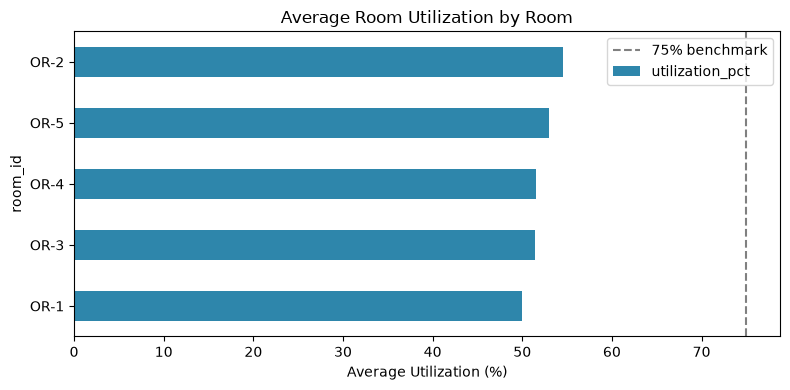

In [5]:
room_avg = metrics.daily_room_summary.groupby("room_id")["utilization_pct"].mean().sort_values()
ax = room_avg.plot(kind="barh", figsize=(8, 4), color="#2E86AB")
ax.axvline(75, color="gray", linestyle="--", label="75% benchmark")
ax.set_xlabel("Average Utilization (%)")
ax.set_title("Average Room Utilization by Room")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Look at delay, overrun, and turnaround patterns

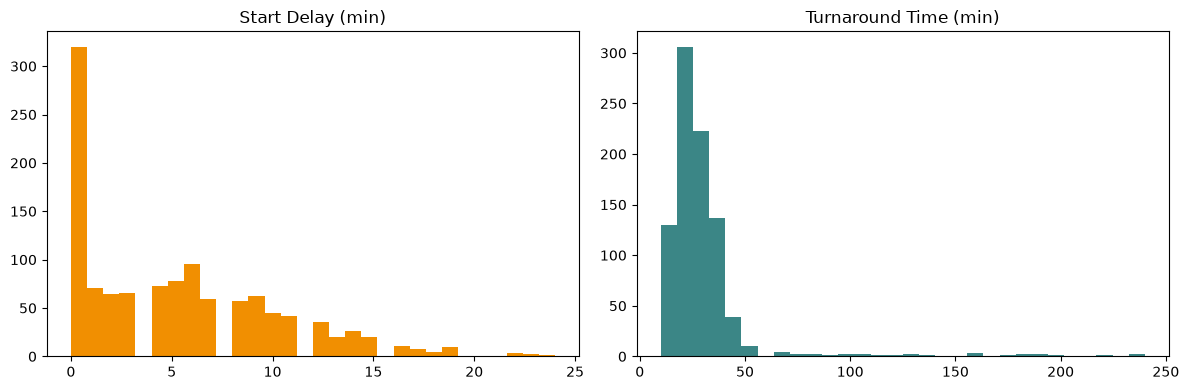

In [6]:
completed = metrics.case_level[metrics.case_level["is_completed"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(completed["start_delay_min"].dropna(), bins=30, color="#F18F01")
axes[0].set_title("Start Delay (min)")

axes[1].hist(metrics.turnaround_times["turnaround_min"].dropna(), bins=30, color="#3B8686")
axes[1].set_title("Turnaround Time (min)")
plt.tight_layout()
plt.show()

## 5. Which surgeons/blocks have the most room for improvement?

Surgeons with high cancellation rates or large overruns are often the biggest
levers for utilization improvement — not because of blame, but because their
blocks are where the most unpredictable time is being lost.

In [7]:
metrics.surgeon_summary.sort_values("cancellation_rate_pct", ascending=False).head(10)

,surgeon_id,n_scheduled,n_completed,n_cancelled,cancellation_rate_pct,avg_start_delay_min,avg_overrun_min,avg_scheduled_duration_min,avg_actual_duration_min,median_case_accuracy_pct
10,SUR-007,89,78,11,12.359551,4.153846,8.961538,68.719101,72.756410,96.635338
8,SUR-006,96,88,8,8.333333,5.818182,10.954545,81.718750,84.590909,94.689850
4,SUR-012,110,101,9,8.181818,5.000000,11.594059,79.181818,84.148515,97.619048
9,SUR-004,94,87,7,7.446809,5.954023,10.597701,72.276596,72.804598,96.774194
5,SUR-009,104,97,7,6.730769,4.948454,10.484536,77.576923,80.402062,95.876289
11,SUR-001,76,71,5,6.578947,5.295775,14.492958,85.289474,94.338028,92.941176
7,SUR-005,99,93,6,6.060606,4.645161,11.720430,73.959596,77.892473,93.750000
2,SUR-011,118,112,6,5.084746,4.696429,10.508929,73.033898,74.696429,93.861852
6,SUR-008,102,98,4,3.921569,5.581633,10.714286,77.823529,79.346939,94.722222
3,SUR-003,113,109,4,3.539823,5.431193,11.724771,76.044248,80.247706,94.594595


## 6. Simulate schedule-optimization scenarios

The simulator asks: *if we improved turnaround time, cut start delays, and
tightened overruns by some amount, how much additional capacity would that
free up — without extending operating hours?*

We compare three scenarios: conservative, moderate, and aggressive process
improvement.

In [8]:
scenarios = [
    simulate_schedule_optimization(
        metrics.daily_room_summary,
        turnaround_reduction_min=5, start_delay_reduction_pct=15, overrun_reduction_pct=10,
        scenario_name="conservative"
    ),
    simulate_schedule_optimization(
        metrics.daily_room_summary,
        turnaround_reduction_min=10, start_delay_reduction_pct=30, overrun_reduction_pct=25,
        scenario_name="moderate"
    ),
    simulate_schedule_optimization(
        metrics.daily_room_summary,
        turnaround_reduction_min=15, start_delay_reduction_pct=50, overrun_reduction_pct=40,
        scenario_name="aggressive"
    ),
]

compare_scenarios(scenarios)[[
    "scenario_name", "total_reclaimed_minutes",
    "est_additional_cases_from_efficiency_only",
    "baseline_utilization_pct", "projected_utilization_pct"
]]

,scenario_name,total_reclaimed_minutes,est_additional_cases_from_efficiency_only,baseline_utilization_pct,projected_utilization_pct
0,conservative,5940.2,74.4,52.1,55.4
1,moderate,12546.2,157.2,52.1,59.0
2,aggressive,19230.0,241.0,52.1,62.6


## 7. Takeaways

- Even the **moderate** scenario — a realistic ask (10-minute faster turnarounds,
  30% less start delay, 25% less overrun) — recovers a meaningful number of
  case-equivalents per month without adding a single operating hour.
- The gap between `est_additional_cases_from_efficiency_only` and
  `est_additional_cases_incl_existing_idle` shows how much *already-idle* block
  time exists on top of process-improvement gains — that's often the more
  actionable number for a block-time reallocation conversation.
- These are transparent, assumption-driven estimates (see `simulate.py`
  docstring), not a full discrete-event simulation — every number is traceable
  back to a stated input so it can be challenged and refined by OR leadership.